In [1]:
from Objects.Transformations import *
from Objects.WSBM import *
from Objects.TWSBMInstance import *

from Computation.Computation import *
from Computation.ExtraMetrics import *

from Plotting.Plotting import *
from Plotting.ArtisticPlotting import *
import cloudpickle

from itertools import tee, islice, chain
def inserted(iterable, index, value):
	"""Renvoie un itérateur où `value` est inséré juste avant l’élément à la position `index`."""
	it1, it2 = tee(iterable)
	first  = islice(it1, index)
	second = islice(it2, index, None)
	return chain(first, [value], second)

In [ ]:
def plot_embedding_for(transforms, subfolder, light = True):
	for emb_mode, p22 in product(EMB_MODES[:1], P22S[:1]):
		print(f"Simulating for emb_mode = {emb_mode}, p22 = {p22}")
		metrics = {}
		for rho, pi in product(RHOS, PIS):
			metrics[(rho, pi)] = {}
			if light: 	model_params = list(inserted(product([0.1, 0.9], repeat = 2), 2, (0.5, 0.5)))
			else:		model_params = list(product([0.1, 0.5, 0.9], repeat = 2))
			for model, (p12, p11) in product([betaWSBM], model_params):
				m = model(rho, pi, (p11, p12), p22 = p22)
				A, Z = m(42)
				metrics[(rho, pi)][m] = {}
				for t in transforms:
					print(f"Simulating for rho={rho}, pi={pi}, model={model.name}, transformation={t.id}")
					metrics[(rho, pi)][m][t] = TWSBMInstance(model = m, transformation = t, A = t(A), Z = Z, emb_mode = emb_mode)

		plotter = Plotter(folder_path=emb_mode_p22_path_str(emb_mode, p22))
		prefix = "Light" if light else "Extensive"
		for rho, pi in product(RHOS, PIS):
			plotter.plot_embedding(rho, pi, metrics[(rho, pi)], subfolder = f"{prefix}{subfolder}")

"""
light = True
plot_embedding_for(TRANSFORMS,     "Beta/Transforms", light = light)
plot_embedding_for(TRANSFORMS_POW, "Beta/Powers", light = light)
plot_embedding_for(TRANSFORMS_QTL, "Beta/Quantiles", light = light)

light = False
plot_embedding_for(TRANSFORMS,     "Beta/Transforms", light = light)
plot_embedding_for(TRANSFORMS_POW, "Beta/Powers", light = light)
plot_embedding_for(TRANSFORMS_QTL, "Beta/Quantiles", light = light)"""

'\nlight = True\nplot_embedding_for(TRANSFORMS,     "Beta/Transforms", light = light)\nplot_embedding_for(TRANSFORMS_POW, "Beta/Powers", light = light)\nplot_embedding_for(TRANSFORMS_QTL, "Beta/Quantiles", light = light)\n\nlight = False\nplot_embedding_for(TRANSFORMS,     "Beta/Transforms", light = light)\nplot_embedding_for(TRANSFORMS_POW, "Beta/Powers", light = light)\nplot_embedding_for(TRANSFORMS_QTL, "Beta/Quantiles", light = light)'

In [ ]:
def plot_embedding_for(transforms, subfolder, light = True):  
	for emb_mode, p22 in product(EMB_MODES[:1], P22S[:1]):
		print(f"Simulating for emb_mode = {emb_mode}, p22 = {p22}")
		metrics = {}
		for rho, pi in product(RHOS, PIS):
			metrics[(rho, pi)] = {}
			if light: 	model_params = list(inserted(product([0.1, 0.9], repeat = 2), 2, (0.5, 0.5)))
			else:		model_params = list(product([0.1, 0.5, 0.9], repeat = 2))
			for model, (p12, p11) in product([lognormWSBM], model_params):
				m = model(rho, pi, (p11, p12), p22 = p22)
				A, Z = m(42)
				metrics[(rho, pi)][m] = {}
				for t in transforms:
					print(f"Simulating for rho={rho}, pi={pi}, model={model.name}, transformation={t.name}")
					G = TWSBMInstance(model = m, transformation = t, A = t(A), Z = Z, emb_mode = emb_mode)
					metrics[(rho, pi)][m][t] = G

		plotter = Plotter(folder_path=emb_mode_p22_path_str(emb_mode, p22))
		prefix = "Light" if light else "Extensive"
		for rho, pi in product(RHOS, PIS):
			plotter.plot_embedding(rho, pi, metrics[(rho, pi)], subfolder = f"{prefix}{subfolder}")

"""
light = True
plot_embedding_for(TRANSFORMS,     "Log/Transforms", light = light)
plot_embedding_for(TRANSFORMS_POW, "Log/Powers", light = light)
plot_embedding_for(TRANSFORMS_QTL, "Log/Quantiles", light = light)

light = False
plot_embedding_for(TRANSFORMS,     "Log/Transforms", light = light)
plot_embedding_for(TRANSFORMS_POW, "Log/Powers", light = light)
plot_embedding_for(TRANSFORMS_QTL, "Log/Quantiles", light = light)"""

'\nlight = True\nplot_embedding_for(TRANSFORMS,     "Log/Transforms", light = light)\nplot_embedding_for(TRANSFORMS_POW, "Log/Powers", light = light)\nplot_embedding_for(TRANSFORMS_QTL, "Log/Quantiles", light = light)\n\nlight = False\nplot_embedding_for(TRANSFORMS,     "Log/Transforms", light = light)\nplot_embedding_for(TRANSFORMS_POW, "Log/Powers", light = light)\nplot_embedding_for(TRANSFORMS_QTL, "Log/Quantiles", light = light)'

In [2]:
emb_mode = 'sqrt-scaled'
p22 = 'fixed'
n_batch = 5

In [126]:
import os
import numpy as np

def merge_dico(file_dir, prefixes, n_batch):
	for b in range(n_batch):
		b_path = os.path.join(file_dir, f"{b}.npz")
		if os.path.exists(b_path):
			merged = dict(np.load(b_path))
			normalized = {}
			for key, val in merged.items():
				id_part, *rest = key.split('_', 1)
				if id_part.startswith('Pow-'):
					# parse the numeric part, then format to two decimals
					num = float(id_part.split('-', 1)[1])
					new_id = f'P-{num:.2f}'
					# rebuild the key
					suffix = rest[0] if rest else ''
					normalized_key = f'{new_id}_{suffix}' if suffix else new_id
				else:
					normalized_key = key
				normalized[normalized_key] = val
			merged = normalized
		else:
			merged = {}
		for p in prefixes:
			p_path = os.path.join(file_dir, f"{p}{b}.npz")
			if os.path.exists(p_path):
				merged.update(dict(np.load(p_path)))
				os.remove(p_path)
		np.savez_compressed(b_path, **merged)

prefixes = []
path     = f"Computation/{emb_mode_p22_path_str(emb_mode, p22)}"
for rho, pi, model in RHOS_PIS_MODELS:
	file_dir = f"{path}/{model.__name__}_{rho}_{pi}".replace(".", "")
	merge_dico(file_dir, prefixes, n_batch)

In [3]:
path = f"Computation/{emb_mode_p22_path_str(emb_mode, p22)}"
metrics_g = {}
metrics_g_1st_layer = {}
for rho, pi, model in RHOS_PIS_MODELS:
	file = f"{path}/{model.__name__}_{rho}_{pi}".replace(".", "")
	grids_stacked = [np.load(f"{file}/{b}.npz") for b in range(n_batch)]
	metrics_g[(rho, pi, model)] = {}
	metrics_g_1st_layer[(rho, pi, model)] = {}
	for t in TRANSFORMS_EXT:
		metrics_g[(rho, pi, model)][t] = {}
		metrics_g[(rho, pi, model)][t]['std'] = {}
		metrics_g_1st_layer[(rho, pi, model)][t] = {}
		for metric in VANILLA_METRICS_ID:
			g_stack = np.concatenate([g[f'{t.id}_{metric}'] for g in grids_stacked], axis = -1)
			mean = np.mean(g_stack, axis = -1)
			std  = np.std(g_stack, axis = -1)
			metrics_g[(rho, pi, model)][t][metric] = mean
			metrics_g[(rho, pi, model)][t]['std'][metric] = std
			metrics_g_1st_layer[(rho, pi, model)][t][metric] = g_stack[:, :, 0]
		for metric in GATED_CHERNOFFS_ID:
			gating_f = GATING_FUNCTIONS[metric]
			g_stack = np.concatenate([g[f'{t.id}_{metric[1:]}'] * gating_f(g[f'{t.id}_GMM_score'])
							 for g in grids_stacked], axis = -1)
			mean = np.mean(g_stack, axis = -1)
			std  = np.std(g_stack, axis = -1)
			metrics_g[(rho, pi, model)][t][metric] = mean
			metrics_g[(rho, pi, model)][t]['std'][metric] = std
			metrics_g_1st_layer[(rho, pi, model)][t][metric] = g_stack[:, :, 0]

metrics_g = aggregate_metrics(metrics_g)
metrics_g_1st_layer = aggregate_metrics(metrics_g_1st_layer)

metrics_g = best_transform_metrics(metrics_g)

for model in MODELS:
	metrics_g[model] = best_transform_metrics(metrics_g[model])

for rho, pi, model in RHOS_PIS_MODELS:
	m = metrics_g[(rho, pi, model)]
	metrics_g[(rho, pi, model)] = best_transform_metrics(m)
	for t in TRANSFORMS_EXT:
		m = metrics_g[(rho, pi, model)][t]
		metrics_g[(rho, pi, model)][t] = correlation(m)
		metrics_g[(rho, pi, model)][t] = bias(m)

with open('Computation/metrics_g.cpkl', 'wb') as f:
	cloudpickle.dump(metrics_g, f)
with open('Computation/metrics_g_1st_layer.cpkl', 'wb') as f:
	cloudpickle.dump(metrics_g_1st_layer, f)
plotter = Plotter(folder_path=emb_mode_p22_path_str(emb_mode, p22))

c:\Users\Nicol\AppData\Local\Programs\Python\Python39\lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\Nicol\AppData\Local\Programs\Python\Python39\lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\Nicol\Documents\EPFL\MA6\Project\Code\Computation\ExtraMetrics.py:84: RuntimeWarning: divide by zero encountered in log
  return np.log(pred / (true + eps))
c:\Users\Nicol\AppData\Local\Programs\Python\Python39\lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\Nicol\AppData\Local\Programs\Python\Python39\lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\Nicol\Documents\EPFL\MA6\Project\Code\Computation

In [2]:
emb_mode = 'sqrt-scaled'
p22 = 'fixed'
n_batch = 2

with open('Computation/metrics_g.cpkl', 'rb') as f:
	metrics_g = cloudpickle.load(f)
with open('Computation/metrics_g_1st_layer.cpkl', 'rb') as f:
	metrics_g_1st_layer = cloudpickle.load(f)
plotter = Plotter(folder_path=emb_mode_p22_path_str(emb_mode, p22))

In [ ]:
# Trouver meilleurs param Sigmoid pour C_true

plotter.plot_scatter_Rand_vs_Chernoff(metrics_g_1st_layer, n_points_ratio_displayed=0.1)

In [ ]:
# Grill heatmap S-Corr(C, R), Corr(C, GMM), Corr(GMM, R) pour C in [6], Corr(C_true, C) pour C in [2x2]
# 13 transforms x 9 graphs (rho x pi) | total par transform, rho, pi et modèle
# 2 models

In [8]:
for rho, pi, model in RHOS_PIS_MODELS:
	m = metrics_g[(rho, pi, model)]
	plotter.plot_best_transform_heatmaps(rho, pi, model, m, gated = False)
	plotter.plot_best_transform_heatmaps(rho, pi, model, m, gated = True)

In [6]:
# TODO : std (en vérité moyenne des stds)

for model in MODELS:
	for mode in ['No regret', 'With regret']:
		for transforms, name in zip([TRANSFORMS, TRANSFORMS_POW, TRANSFORMS_QTL], 
						['Transforms', 'Powers', 'Quantiles']):
			plotter.plot_transforms_rand(model, metrics_g[model], mode = mode, 
								transforms = transforms.copy(), chernoffs = [], name = name)
		plotter.plot_transforms_rand(model, metrics_g[model], mode = mode, 
							transforms = TRANSFORMS_QTL[2:3], chernoffs = CHERNOFFS_ID.copy(), name = "Chernoffs")

	for chernoff in CHERNOFFS_ID:
		plotter.plot_transforms_rand_for_best_transform(model, metrics_g[model], chernoff)

In [ ]:
"""
for rho, pi, model in RHOS_PIS_MODELS:
	for t in TRANSFORMS:
		m = metrics_g[(rho, pi, model)][t]
		plotter.plot_metrics_heatmap(rho, pi, model, t, m, shared=False, log=True)

for rho, pi, model in RHOS_PIS_MODELS:
	for t in TRANSFORMS:
		m = metrics_g[(rho, pi, model)][t]
		plotter.plot_bias_heatmap(rho, pi, model, t, m, log = True)"""

#corr(R,GMM), corr(C,GMM) (option verbose corr / simple corr)

rho, pi, model, t = 0.25, 0.1, betaWSBM, QuantileTransform(q=0.01)
m = metrics_g[(rho, pi, model)][t]
plotter.plot_metrics_heatmap(rho, pi, model, t, m, shared=False, log=True)
#plotter.plot_bias_heatmap(rho, pi, model, t, m, log = True)

In [3]:
import numpy as np
from itertools import product

shifts  = np.concatenate([#np.linspace(-45, -25, 10, endpoint=False), 
					  #np.linspace(-25, -15, 10, endpoint=False), 
					  np.linspace(-15, -5, 20, endpoint=False),
					  np.linspace(-5, 5, 41, endpoint=True)])
windows = np.concatenate([np.linspace(0, 1.25, 20, endpoint=False), 
					  np.linspace(1.25, 2.5, 10, endpoint=False), 
					  np.linspace(2.5, 5, 10, endpoint=True)])


best_rand_avg = {model: {C: {} for C in GATED_CHERNOFFS_ID} for model in MODELS}

for model in MODELS:
	base = f"Computation/{emb_mode_p22_path_str(emb_mode, p22)}/{model.__name__}".replace('.', '')
	R = len(RHOS) * len(PIS)
	B = n_batch
	T = len(TRANSFORMS_EXT)

	grids = [[np.load(f"{base}_{rho}_{pi}/{b}".replace('.', '') + '.npz') for b in range(B)] for rho, pi in product(RHOS, PIS)]
	rand_shape = grids[0][0][f"{TRANSFORMS_EXT[0].id}_Rand"].shape
	H, W = rand_shape[0], rand_shape[1]

	rand_stack = np.stack([g[f"{t.id}_Rand"] for batch in grids for t in TRANSFORMS_EXT for g in batch], axis=0).reshape(R, T, B, H, W)
	rand_mean = rand_stack.mean(axis=2).transpose(0,2,3,1)  # (R, H, W, T)

	gmm_stack = np.stack([g[f"{t.id}_GMM_score"] for batch in grids for t in TRANSFORMS_EXT for g in batch], axis=0).reshape(R, T, B, H, W)
	gmm_mean = gmm_stack.mean(axis=2).transpose(0,2,3,1)    # (R, H, W, T)

	C_count = len(GATED_CHERNOFFS_ID)
	metrics = np.stack(
		[g[f"{t.id}_{C[1:]}"]
		 for C in GATED_CHERNOFFS_ID
		 for t in TRANSFORMS_EXT
		 for batch in grids
		 for g in batch],
		axis=0
	).reshape(C_count, T, R, B, H, W)
	metrics = metrics.mean(axis=3).transpose(0,2,3,4,1)  # (C_count, R, H, W, T)

	for c_idx, C in enumerate(GATED_CHERNOFFS_ID):
		M0 = metrics[c_idx]  # (R, H, W, T)
		Arg0 = np.argmax(M0, axis=-1)  # (R, H, W)
		best_rand_avg[model][C]["no gating"] = (np.take_along_axis(rand_mean, Arg0[..., None], axis=-1).mean())

		for x0, w in product(shifts, windows):
			gate = sigmoid_w95(gmm_mean, x0, w)  # (R, H, W, T)
			weighted = M0 * gate
			Arg_hp = np.argmax(weighted, axis=-1)  # (R, H, W)
			best_rand_avg[model][C][(x0, w)] = (np.take_along_axis(rand_mean, Arg_hp[..., None], axis=-1).mean())

with open('Computation/best_rand_avg.cpkl', 'wb') as f:
	cloudpickle.dump(best_rand_avg, f)

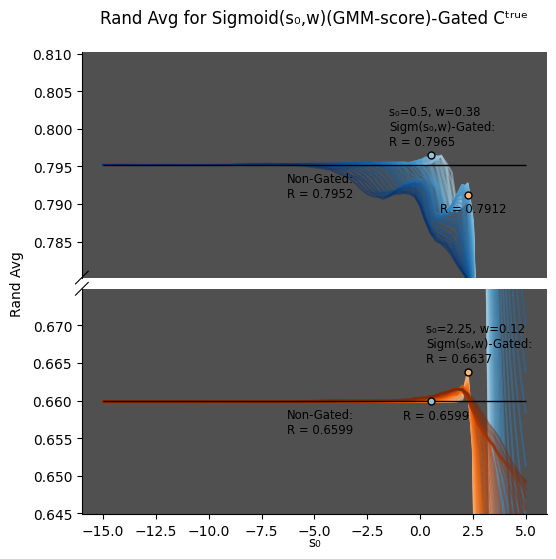

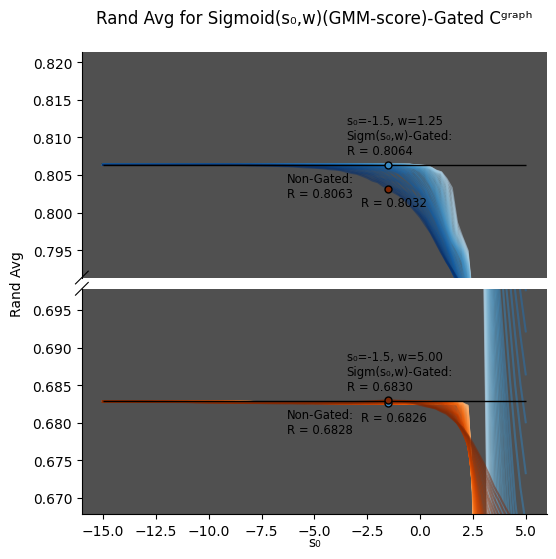

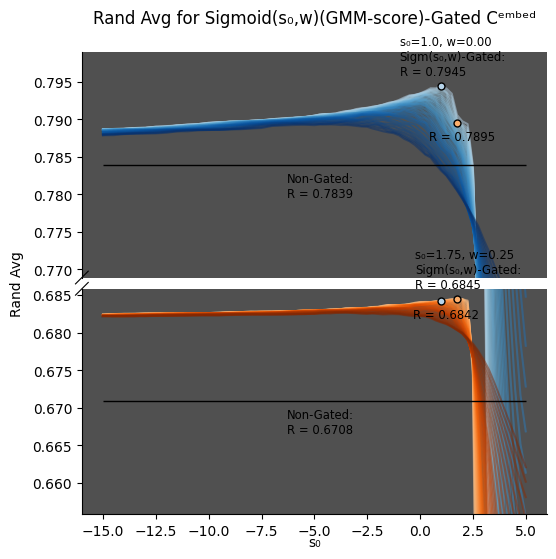

In [ ]:
from brokenaxes import brokenaxes
import matplotlib.pyplot as plt
import numpy as np

def plot_by_metric_broken_dynamic(C, best_rand_avg, shifts, windows, models, model_colormaps):
	# Define y-limits around the "no gating" baseline
	ylim_size = 0.015
	ylim0 = best_rand_avg[models[1]][C]["no gating"] + np.array([-1, 1]) * ylim_size
	ylim1 = best_rand_avg[models[0]][C]["no gating"] + np.array([-1, 1]) * ylim_size

	fig = plt.figure(figsize=(6, 6))
	bax = brokenaxes(
		ylims=(ylim0, ylim1),
		hspace=.05,
		despine=True,
		fig=fig)

	for ax in bax.axs:
		ax.set_facecolor('#505050')  # anthracite

	# 2) Plot curves and annotate
	max_info = {}
	for model in models:
		# Plot sigmoid curves per window
		cmap = plt.get_cmap(model_colormaps[model])
		colors = cmap(np.linspace(0.3, 1.0, len(windows)))
		for idx, w in enumerate(windows):
			y_vals = [best_rand_avg[model][C][(x0, w)] for x0 in shifts]
			bax.plot(shifts, y_vals, color=colors[idx], alpha=0.5)

		# Horizontal line for no gating with annotation
		y0 = best_rand_avg[model][C]["no gating"]
		bax.hlines(y0, xmin=min(shifts), xmax=max(shifts), linestyles='-', linewidth=1, colors='black')
		mid_x = (min(shifts) + max(shifts)) / 2
		bax.annotate(
			f"Non-Gated:\nR = {y0:.4f}",
			xy=(mid_x, y0), xytext=(-20, -15), textcoords='offset points', va='center', fontsize='small'
		)

		# Find max Rand Avg across (x0, w) for sigmoid
		best_val = -np.inf
		best_params = None
		
		for x0 in shifts:
			for w in windows:
				val = best_rand_avg[model][C][(x0, w)]
				if val > best_val:
					best_val = val
					best_params = (x0, w)
		max_info[model] = (best_params, best_val)

	# Annotate max points and compare across models
	for model in models:
		cmap = plt.get_cmap(model_colormaps[model])
		colors = cmap(np.linspace(0.3, 1.0, len(windows)))
		(x0_m, w_m), best_val = max_info[model]
		color_model = colors[np.where(windows == w_m)[0][0]]

		# Marker for model max
		bax.scatter([x0_m], [best_val], marker='o', s=25, edgecolors='k', facecolors=color_model, zorder=5)
		bax.annotate(
			f"s₀={x0_m}, w={w_m:.2f}\nSigm(s₀,w)-Gated:\nR = {best_val:.4f}",
			xy=(x0_m, best_val), textcoords='offset points', xytext=(-30, 7.5), fontsize='small'
		)

		# Mark and label other models at the same (x0, w)
		for other in models:
			if other is not model:
				val_other = best_rand_avg[other][C][(x0_m, w_m)]
				bax.scatter([x0_m], [val_other], marker='o', s=25, edgecolors='k', facecolors=color_model, zorder=5)
				bax.annotate(
					f"R = {val_other:.4f}",
					xy=(x0_m, val_other), textcoords='offset points', fontsize='small', xytext=(-20, -12.5),
				)

	bax.set_xlabel('s₀')
	bax.set_ylabel('Rand Avg\n')
	bax.set_title(f"Rand Avg for Sigmoid(s₀,w)(GMM-score)-Gated {CHERNOFFS_ID_COSMETIC_MAP[C[1:]]}\n")
	plt.show()


model_colormaps = dict(zip(MODELS, ['Blues', 'Oranges']))
for C in GATED_CHERNOFFS_ID:
	plot_by_metric_broken_dynamic(
		C,
		best_rand_avg,
		shifts,
		windows,
		MODELS,
		model_colormaps
	)

# TODO
# beta, log couleur (spectre window) en légende
# corriger emplacement texte vers -15
# alléger ticks en x
# mettre max

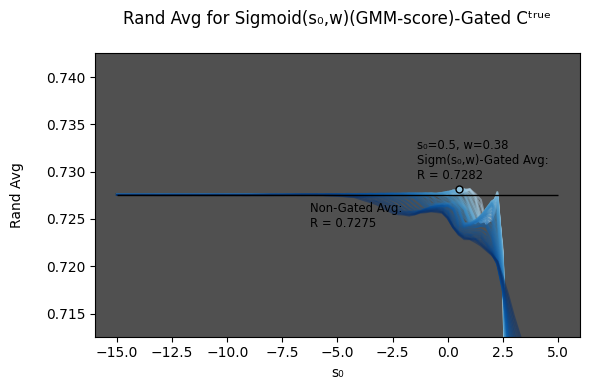

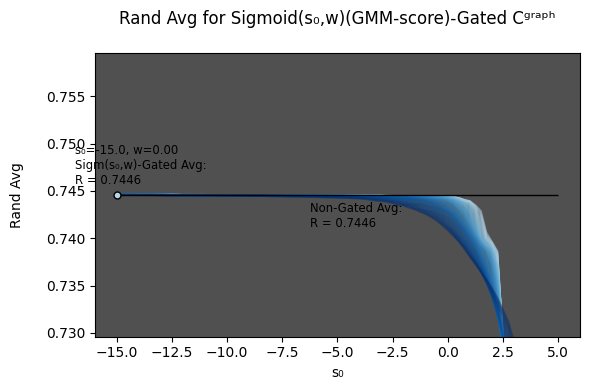

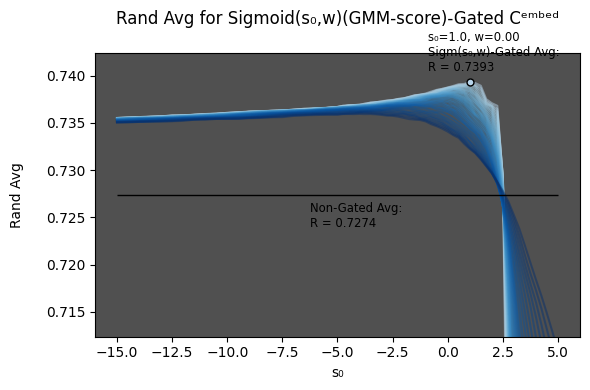

In [7]:
import matplotlib.pyplot as plt
import numpy as np

def plot_by_metric_average(C, best_rand_avg, shifts, windows, models, model_colormaps):
    """
    Même style visuel que plot_by_metric_broken_dynamic, 
    mais sans brokenaxes et en moyennant les deux modèles.
    """
    # mêmes marges autour de la baseline "no gating"
    ylim_size = 0.015
    # calcul de la baseline moyenne
    y0_vals = [best_rand_avg[m][C]["no gating"] for m in models]
    avg_baseline = np.mean(y0_vals)
    ylim = avg_baseline + np.array([-1, 1]) * ylim_size

    # figure et axe unique
    fig = plt.figure(figsize=(6, 4))
    ax = fig.add_subplot(1, 1, 1)
    ax.set_facecolor('#505050')  # anthracite
    ax.set_ylim(*ylim)

    # tracé des courbes moyennées par fenêtre
    cmap = plt.get_cmap(model_colormaps[models[0]])
    colors = cmap(np.linspace(0.3, 1.0, len(windows)))

    # stocker pour repérage du max
    max_val = -np.inf
    max_params = None

    for idx, w in enumerate(windows):
        # moyenne des deux modèles pour chaque s₀
        y_vals = [
            (best_rand_avg[models[0]][C][(x0, w)] +
             best_rand_avg[models[1]][C][(x0, w)]) / 2
            for x0 in shifts
        ]
        ax.plot(shifts, y_vals, color=colors[idx], alpha=0.5)

        # détection du point max sur cette fenêtre
        for x0, y in zip(shifts, y_vals):
            if y > max_val:
                max_val = y
                max_params = (x0, w)

    # ligne horizontale baseline
    ax.hlines(avg_baseline,
              xmin=min(shifts), xmax=max(shifts),
              linestyles='-', linewidth=1, colors='black')
    mid_x = (min(shifts) + max(shifts)) / 2
    ax.annotate(
        f"Non-Gated Avg:\nR = {avg_baseline:.4f}",
        xy=(mid_x, avg_baseline),
        xytext=(-20, -15),
        textcoords='offset points',
        va='center',
        fontsize='small'
    )

    # annotation du point global maximal
    x0_m, w_m = max_params
    idx_max = np.where(windows == w_m)[0][0]
    color_max = colors[idx_max]
    ax.scatter([x0_m], [max_val],
               marker='o', s=25,
               edgecolors='k', facecolors=color_max,
               zorder=5)
    ax.annotate(
        f"s₀={x0_m}, w={w_m:.2f}\nSigm(s₀,w)-Gated Avg:\nR = {max_val:.4f}",
        xy=(x0_m, max_val),
        textcoords='offset points',
        xytext=(-30, 7.5),
        fontsize='small'
    )

    # labels et titre identiques
    ax.set_xlabel('s₀')
    ax.set_ylabel('Rand Avg\n')
    ax.set_title(
        f"Rand Avg for Sigmoid(s₀,w)(GMM-score)-Gated "
        f"{CHERNOFFS_ID_COSMETIC_MAP[C[1:]]}\n"
    )

    plt.tight_layout()
    plt.show()


# Exemple d'appel
for C in GATED_CHERNOFFS_ID:
    plot_by_metric_average(
        C,
        best_rand_avg,
        shifts,
        windows,
        MODELS,            # doit contenir exactement deux modèles
        model_colormaps    # mapping original des modèles vers leurs colormaps
    )
